In [1]:
import pandas as pd

# Cargar el archivo CSV
df = pd.read_csv('../data/raw/plusvalia_filtered.csv')

In [2]:
# Mostrar las primeras filas del DataFrame
print("Primeras 5 filas del DataFrame:")
print(df.head())

Primeras 5 filas del DataFrame:
                                     ID   CITY  PRICE_USD  BEDROOMS  \
0  b69187e1-f818-437c-af3e-024aa37fe81e  Quito     830000         3   
1  d4a3e280-3e18-4fd7-8b1c-7812586064dc  Quito      92500         3   
2  e46f6714-2896-4578-9525-23260fcbeddc  Quito     105000         3   
3  b75726ee-5334-4649-92de-0e2a9f121b2c  Quito    1430000         6   
4  e0a4f9bd-4024-4342-8a15-0db6cef7a6ca  Quito     214000         3   

   BATHROOMS  PARKING_SPOTS  CONSTRUCTION_AREA_SQM  LATITUDE  LONGITUDE  \
0          4              4                  900.0 -0.213979 -78.432654   
1          2              2                  115.0  0.000537 -78.455751   
2          2              2                  170.0 -0.278383 -78.540906   
3          5              7                 1950.0 -0.211088 -78.497283   
4          3              2                  220.0 -0.162817 -78.342247   

                                                LINK  
0  https://www.plusvalia.com/propie

In [3]:
# Mostrar el número de valores nulos por columna
print("\nValores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
ID                       0
CITY                     0
PRICE_USD                0
BEDROOMS                 0
BATHROOMS                0
PARKING_SPOTS            0
CONSTRUCTION_AREA_SQM    0
LATITUDE                 0
LONGITUDE                0
LINK                     0
dtype: int64


In [4]:
# Verificar y eliminar filas duplicadas
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - df.shape[0]
print(f"\nNúmero de filas duplicadas eliminadas: {duplicates_removed}")
print(f"Número de filas después de eliminar duplicados: {df.shape[0]}")


Número de filas duplicadas eliminadas: 0
Número de filas después de eliminar duplicados: 7460


In [5]:
# Estadísticas descriptivas para columnas numéricas
print("\nEstadísticas descriptivas de columnas numéricas:")
print(df.describe())


Estadísticas descriptivas de columnas numéricas:
          PRICE_USD     BEDROOMS    BATHROOMS  PARKING_SPOTS  \
count  7.460000e+03  7460.000000  7460.000000    7460.000000   
mean   5.758762e+05     3.975067     3.510054       3.011528   
std    1.962910e+07     1.985514     1.925696      28.578169   
min    1.000000e+00     1.000000     1.000000       1.000000   
25%    1.399000e+05     3.000000     2.000000       2.000000   
50%    2.467000e+05     3.000000     3.000000       2.000000   
75%    4.250000e+05     4.000000     4.000000       3.000000   
max    1.695000e+09    40.000000    50.000000    2464.000000   

       CONSTRUCTION_AREA_SQM     LATITUDE    LONGITUDE  
count           7.460000e+03  7460.000000  7460.000000  
mean            1.581556e+04    -0.907070   -79.041646  
std             4.690248e+05     0.921506     0.757000  
min             4.000000e+01    -2.268246   -80.789544  
25%             1.900000e+02    -2.084467   -79.872386  
50%             3.000000e+02   

In [6]:
# Valores únicos para columnas categóricas (o columnas con pocos valores únicos)
print("\nValores únicos de la columna CITY:")
print(df['CITY'].value_counts())


Valores únicos de la columna CITY:
CITY
Quito        4552
Guayaquil    2670
Manta         238
Name: count, dtype: int64


In [7]:
# Eliminar columnas irrelevantes para el modelado
df_cleaned = df.drop(columns=['ID', 'LINK'])
print("\nColumnas después de eliminar ID y LINK:")
print(df_cleaned.head())


Columnas después de eliminar ID y LINK:
    CITY  PRICE_USD  BEDROOMS  BATHROOMS  PARKING_SPOTS  \
0  Quito     830000         3          4              4   
1  Quito      92500         3          2              2   
2  Quito     105000         3          2              2   
3  Quito    1430000         6          5              7   
4  Quito     214000         3          3              2   

   CONSTRUCTION_AREA_SQM  LATITUDE  LONGITUDE  
0                  900.0 -0.213979 -78.432654  
1                  115.0  0.000537 -78.455751  
2                  170.0 -0.278383 -78.540906  
3                 1950.0 -0.211088 -78.497283  
4                  220.0 -0.162817 -78.342247  


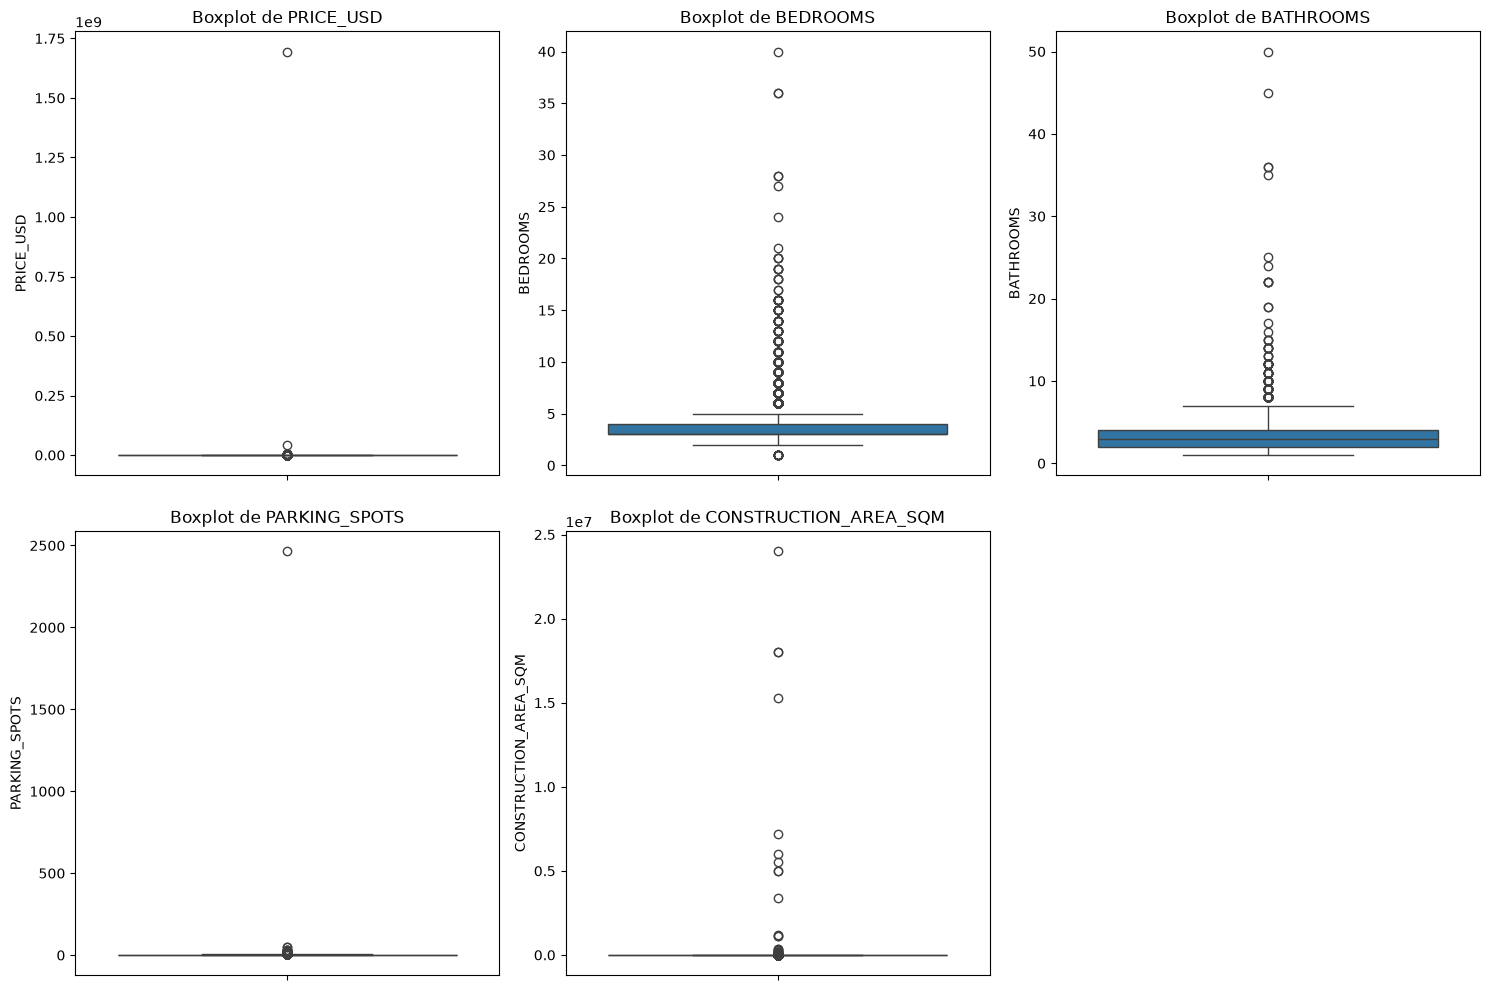


Explicación de un Boxplot y Outliers:
Un boxplot es una herramienta visual que muestra la distribución de un conjunto de datos numéricos a través de sus cuartiles. Los elementos principales son:
- **Línea central (Mediana):** Representa el 50% de los datos. Divide la muestra en dos mitades iguales.
- **Caja (IQR - Rango Intercuartílico):** Se extiende desde el primer cuartil (Q1, 25%) hasta el tercer cuartil (Q3, 75%). Contiene el 50% central de los datos.
- **Bigotes:** Se extienden desde los bordes de la caja hasta el último dato que no se considera atípico. Generalmente, estos límites se calculan como Q1 - 1.5 * IQR y Q3 + 1.5 * IQR.
- **Puntos individuales (Outliers):** Son los puntos de datos que caen fuera de los bigotes. Estos valores se consideran 'atípicos' o 'extremos' con respecto al resto de la distribución. Pueden indicar errores en la recolección de datos, variabilidad inusual o puntos de datos genuinamente extremos que merecen una investigación adicional.
En este boxplo

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columnas que fueron analizadas y tuvieron manejo de outliers
outlier_columns = ['PRICE_USD', 'BEDROOMS', 'BATHROOMS', 'PARKING_SPOTS', 'CONSTRUCTION_AREA_SQM']

# Generar un boxplot para cada columna después del manejo de outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(outlier_columns):
    plt.subplot(2, 3, i + 1)  # Ajusta el layout si tienes más columnas
    sns.boxplot(y=df_cleaned[col])
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

print("\nExplicación de un Boxplot y Outliers:")
print("Un boxplot es una herramienta visual que muestra la distribución de un conjunto de datos numéricos a través de sus cuartiles. Los elementos principales son:")
print("- **Línea central (Mediana):** Representa el 50% de los datos. Divide la muestra en dos mitades iguales.")
print("- **Caja (IQR - Rango Intercuartílico):** Se extiende desde el primer cuartil (Q1, 25%) hasta el tercer cuartil (Q3, 75%). Contiene el 50% central de los datos.")
print("- **Bigotes:** Se extienden desde los bordes de la caja hasta el último dato que no se considera atípico. Generalmente, estos límites se calculan como Q1 - 1.5 * IQR y Q3 + 1.5 * IQR.")
print("- **Puntos individuales (Outliers):** Son los puntos de datos que caen fuera de los bigotes. Estos valores se consideran 'atípicos' o 'extremos' con respecto al resto de la distribución. Pueden indicar errores en la recolección de datos, variabilidad inusual o puntos de datos genuinamente extremos que merecen una investigación adicional.")
print("En este boxplot de 'PRICE_USD', los puntos individuales que están muy por encima del bigote superior representan los valores atípicos de los precios, indicando propiedades con precios significativamente más altos que la mayoría.")

In [9]:
# Identificar y manejar outliers en columnas numéricas
# Utilizaremos el percentil 99 como límite superior para 'capping' y un filtro para valores mínimos irrealistas.

# Columnas para tratar outliers
outlier_columns = ['PRICE_USD', 'BEDROOMS', 'BATHROOMS', 'PARKING_SPOTS', 'CONSTRUCTION_AREA_SQM']

# Filtrar valores mínimos irrealistas para PRICE_USD (e.g., 1 USD)
initial_rows_after_drop = df_cleaned.shape[0]
df_cleaned = df_cleaned[df_cleaned['PRICE_USD'] > 100]
rows_removed_min_price = initial_rows_after_drop - df_cleaned.shape[0]
print(f"\nNúmero de filas eliminadas por PRICE_USD irrealista: {rows_removed_min_price}")

for col in outlier_columns:
    if col in df_cleaned.columns:
        upper_bound = df_cleaned[col].quantile(0.99)
        # Capping de valores superiores al percentil 99
        df_cleaned[col] = df_cleaned[col].clip(upper=upper_bound)
        print(f"\nOutliers en '{col}' manejados por capping en el percentil 99 (valor límite: {upper_bound:.2f}).")


Número de filas eliminadas por PRICE_USD irrealista: 1

Outliers en 'PRICE_USD' manejados por capping en el percentil 99 (valor límite: 1600000.00).

Outliers en 'BEDROOMS' manejados por capping en el percentil 99 (valor límite: 12.00).

Outliers en 'BATHROOMS' manejados por capping en el percentil 99 (valor límite: 10.00).

Outliers en 'PARKING_SPOTS' manejados por capping en el percentil 99 (valor límite: 10.00).

Outliers en 'CONSTRUCTION_AREA_SQM' manejados por capping en el percentil 99 (valor límite: 5000.00).


¿Qué es el Percentil 99?
El Percentil 99 es una medida estadística que indica el valor por debajo del cual se encuentra el 99% de las observaciones de un conjunto de datos. En otras palabras, si ordenamos todos los datos de menor a mayor, el percentil 99 es el punto de corte donde solo el 1% de los datos son superiores a él.

¿Por qué se usa para manejar Outliers?
El uso del percentil 99 para el manejo de valores atípicos (outliers) es una técnica conocida como Winsorización o Capping (limitación). Se utiliza por las siguientes razones:

Reducción del Sesgo: Los modelos de Machine Learning (como la Regresión Lineal) son muy sensibles a valores extremadamente altos. Estos valores pueden "arrastrar" la línea de tendencia y sesgar las predicciones.
Preservación de Datos: A diferencia de eliminar las filas (que nos haría perder información valiosa de otras columnas), el capping mantiene la observación pero ajusta el valor extremo a un límite más razonable (el valor del percentil 99).
Estabilidad del Modelo: Al limitar los valores al percentil 99, nos aseguramos de que los datos atípicos no tengan un peso desproporcionado en el entrenamiento del modelo, mejorando su capacidad de generalización.
Robustez: Es una forma pragmática de tratar con errores de medición o casos extremadamente raros que no representan la realidad general del fenómeno que queremos modelar (por ejemplo, una mansión de 50 millones en un dataset de casas promedio).

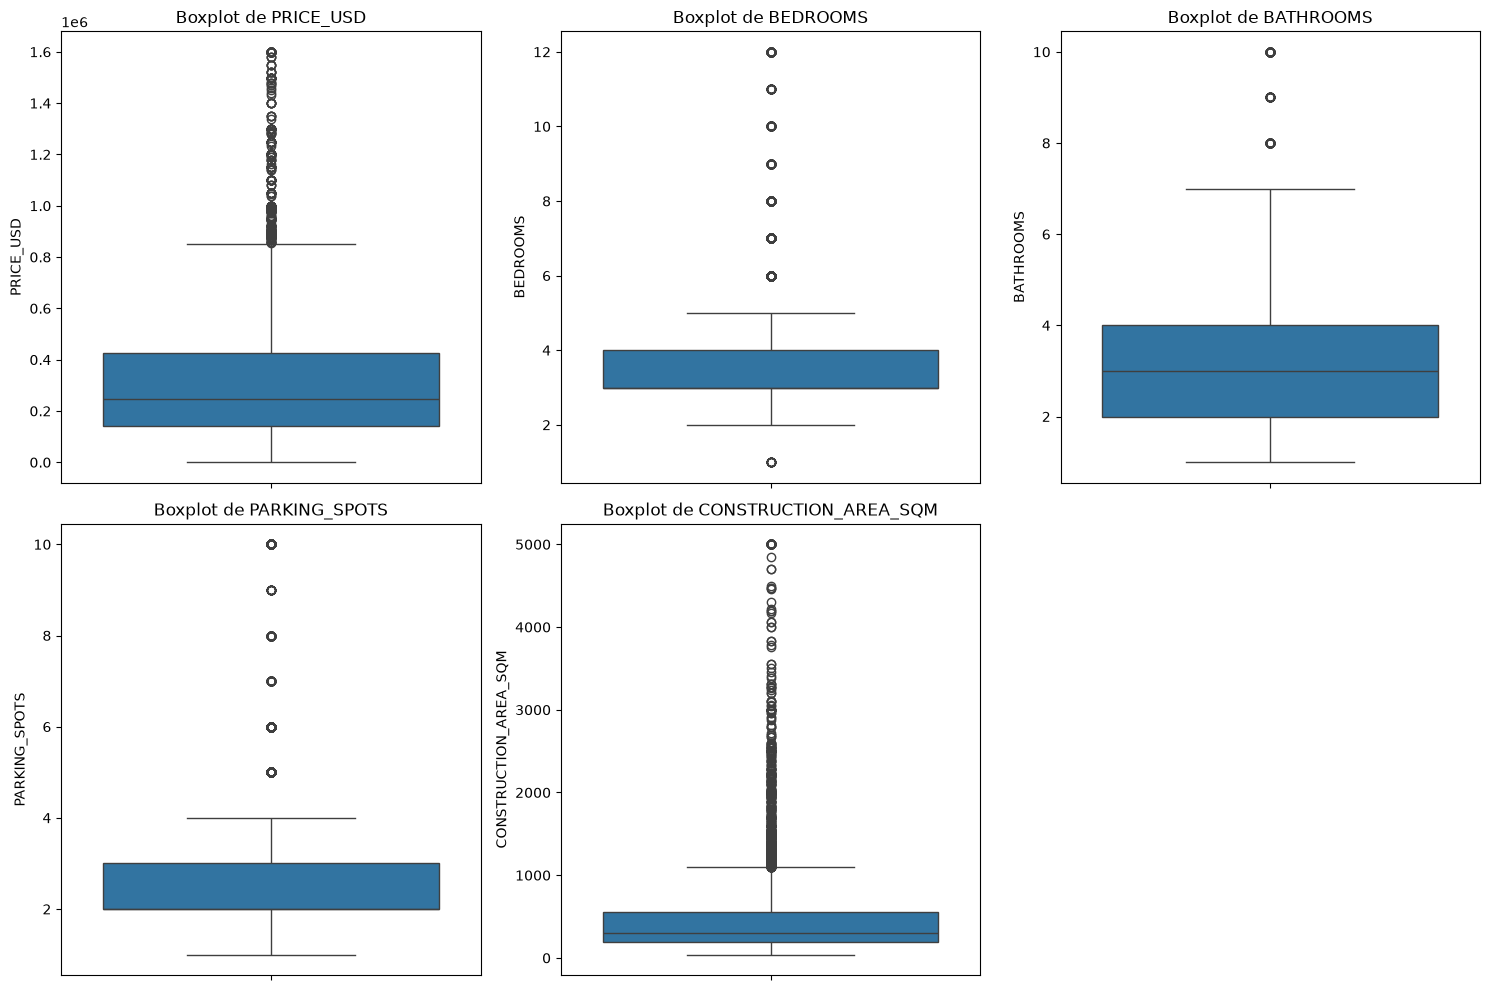


Observación después del manejo de outliers:
En estos boxplots, se puede observar que los valores atípicos extremos han sido 'capsulados' o limitados, lo que se refleja en bigotes más cortos y la ausencia de puntos individuales muy distantes. Esto indica que el proceso de manejo de outliers ha sido aplicado, haciendo que la distribución de estos datos sea más robusta para el modelado.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columnas que fueron analizadas y tuvieron manejo de outliers
outlier_columns = ['PRICE_USD', 'BEDROOMS', 'BATHROOMS', 'PARKING_SPOTS', 'CONSTRUCTION_AREA_SQM']

# Generar un boxplot para cada columna después del manejo de outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(outlier_columns):
    plt.subplot(2, 3, i + 1)  # Ajusta el layout si tienes más columnas
    sns.boxplot(y=df_cleaned[col])
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

print("\nObservación después del manejo de outliers:")
print("En estos boxplots, se puede observar que los valores atípicos extremos han sido 'capsulados' o limitados, lo que se refleja en bigotes más cortos y la ausencia de puntos individuales muy distantes. Esto indica que el proceso de manejo de outliers ha sido aplicado, haciendo que la distribución de estos datos sea más robusta para el modelado.")

In [11]:
print("\nEstadísticas descriptivas después de manejar outliers:")
print(df_cleaned.describe())


Estadísticas descriptivas después de manejar outliers:
          PRICE_USD     BEDROOMS    BATHROOMS  PARKING_SPOTS  \
count  7.459000e+03  7459.000000  7459.000000    7459.000000   
mean   3.384345e+05     3.928543     3.464003       2.624346   
std    2.940333e+05     1.637786     1.505202       1.686053   
min    6.800000e+02     1.000000     1.000000       1.000000   
25%    1.399000e+05     3.000000     2.000000       2.000000   
50%    2.469000e+05     3.000000     3.000000       2.000000   
75%    4.250000e+05     4.000000     4.000000       3.000000   
max    1.600000e+06    12.000000    10.000000      10.000000   

       CONSTRUCTION_AREA_SQM     LATITUDE    LONGITUDE  
count            7459.000000  7459.000000  7459.000000  
mean              514.905751    -0.907163   -79.041727  
std               672.168539     0.921532     0.757019  
min                40.000000    -2.268246   -80.789544  
25%               190.000000    -2.084473   -79.872386  
50%               300.000

In [12]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Instantiate OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the 'CITY' column
categorical_data = df_cleaned[['CITY']]
ohe.fit(categorical_data)
encoded_features = ohe.transform(categorical_data)

# Create a DataFrame with the encoded features and appropriate column names
onehot_df = pd.DataFrame(encoded_features, columns=ohe.get_feature_names_out(['CITY']), index=df_cleaned.index)

# Concatenate the new one-hot encoded DataFrame with the original DataFrame and drop the original 'CITY' column
df_processed = pd.concat([df_cleaned.drop(columns=['CITY']), onehot_df], axis=1)

print("\nDataFrame after One-Hot Encoding on 'CITY' with sklearn.preprocessing.OneHotEncoder:")
print(df_processed.head())
print(f"\nDimensiones del DataFrame final: {df_processed.shape}")


DataFrame after One-Hot Encoding on 'CITY' with sklearn.preprocessing.OneHotEncoder:
   PRICE_USD  BEDROOMS  BATHROOMS  PARKING_SPOTS  CONSTRUCTION_AREA_SQM  \
0     830000         3          4              4                  900.0   
1      92500         3          2              2                  115.0   
2     105000         3          2              2                  170.0   
3    1430000         6          5              7                 1950.0   
4     214000         3          3              2                  220.0   

   LATITUDE  LONGITUDE  CITY_Guayaquil  CITY_Manta  CITY_Quito  
0 -0.213979 -78.432654             0.0         0.0         1.0  
1  0.000537 -78.455751             0.0         0.0         1.0  
2 -0.278383 -78.540906             0.0         0.0         1.0  
3 -0.211088 -78.497283             0.0         0.0         1.0  
4 -0.162817 -78.342247             0.0         0.0         1.0  

Dimensiones del DataFrame final: (7459, 10)


Explicación de parámetros en OneHotEncoder de Sklearn
Al configurar el OneHotEncoder, utilizamos dos parámetros clave para asegurar que el preprocesamiento sea robusto y eficiente:

handle_unknown='ignore':

¿Qué hace?: Este parámetro determina qué debe hacer el codificador si encuentra una categoría nueva (desconocida) durante la fase de transformación (transform) que no estaba presente durante el entrenamiento (fit).
¿Por qué es importante?: Por defecto, sklearn lanza un error si ve una categoría nueva. Al usar 'ignore', en lugar de fallar, el codificador simplemente pondrá ceros en todas las columnas resultantes para esa fila. Esto es crucial en producción para evitar que el modelo se detenga si aparece una ciudad que no estaba en el dataset original.
sparse_output=False:

¿Qué hace?: Define el tipo de estructura de datos que devuelve la función. Si es True (valor por defecto), devuelve una matriz dispersa (sparse matrix). Si es False, devuelve un arreglo denso de NumPy (array).
¿Por qué lo usamos aquí?: Las matrices dispersas son excelentes para ahorrar memoria cuando tienes miles de categorías (donde casi todo son ceros). Sin embargo, como estamos trabajando con pocas ciudades y queremos integrar los resultados directamente en un DataFrame de pandas para visualizarlos fácilmente, un arreglo denso (False) es más cómodo de manipular.

Matriz Dispersa (Sparse Matrix) vs. Arreglo Denso (Dense Array)
En ciencia de datos, la forma en que almacenamos los números en la memoria de la computadora puede cambiar drásticamente el rendimiento.

1. Arreglo Denso (Dense Array)
¿Qué es?: Es una estructura donde se reserva un espacio de memoria para cada celda, sin importar si contiene un número o un cero.
Ejemplo: Si tienes una tabla de 100x100, la computadora guarda los 10,000 valores.
Cuándo usarlo: Cuando la mayoría de tus celdas tienen valores distintos de cero (como en fotografías o precios).
Ventaja: Es fácil de entender y manipular directamente con librerías como Pandas.
2. Matriz Dispersa (Sparse Matrix)
¿Qué es?: Es un formato optimizado que solo guarda la ubicación de los valores distintos de cero. No gasta memoria guardando los ceros.
Ejemplo: En One-Hot Encoding con 1,000 categorías, cada fila tiene un 1 y 999 ceros. La matriz dispersa solo guarda la posición del 1.
Cuándo usarlo: Cuando tienes muchísimos datos y la inmensa mayoría (ej. +95%) son ceros.
Ventaja: Permite trabajar con datasets gigantescos que de otro modo harían que la computadora se quede sin memoria RAM.
Resumen: Usamos sparse_output=False porque nuestro dataset es pequeño y tiene pocas categorías, por lo que preferimos la facilidad de ver los datos directamente como un Arreglo Denso.

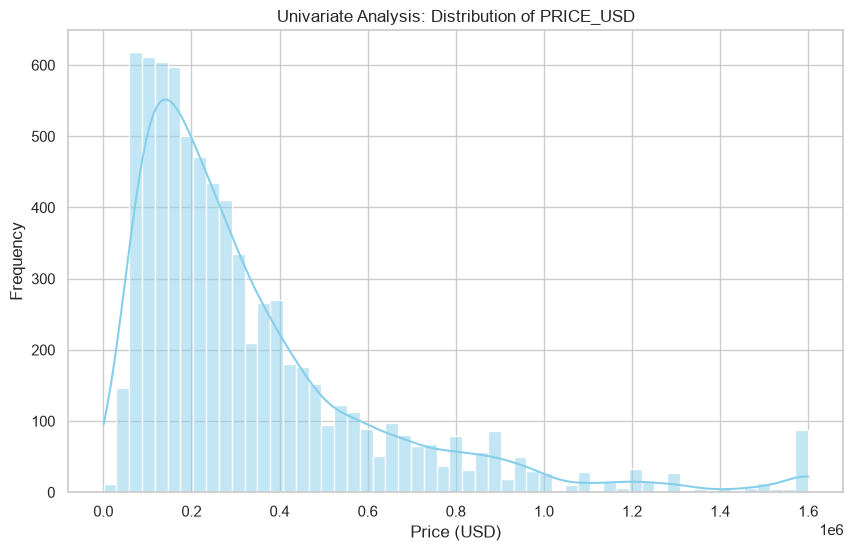

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style for the plots
sns.set_theme(style="whitegrid")

# 1. Univariate Analysis: Distribution of the Target Variable (PRICE_USD)
plt.figure(figsize=(10, 6))
sns.histplot(df_processed['PRICE_USD'], kde=True, color='skyblue')
plt.title('Univariate Analysis: Distribution of PRICE_USD')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()

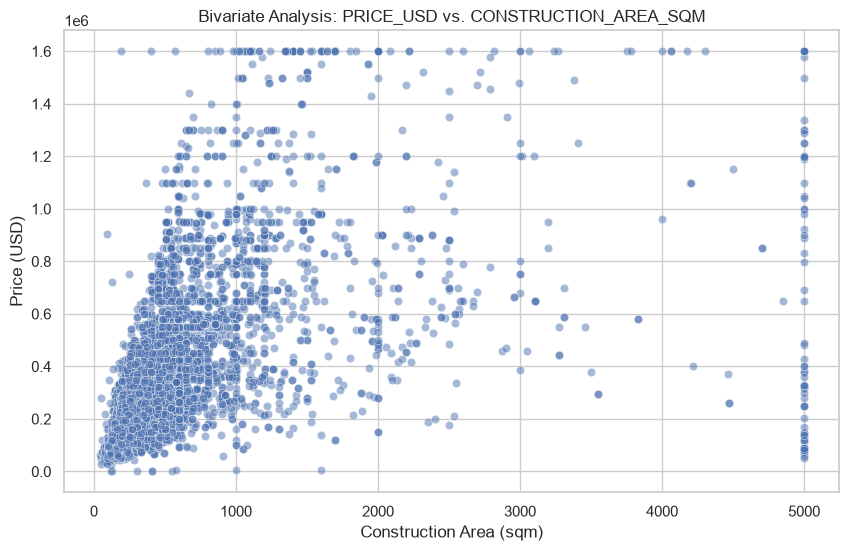

In [14]:
# 2. Bivariate Analysis: Relationship between PRICE_USD and CONSTRUCTION_AREA_SQM
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_processed, x='CONSTRUCTION_AREA_SQM', y='PRICE_USD', alpha=0.5)
plt.title('Bivariate Analysis: PRICE_USD vs. CONSTRUCTION_AREA_SQM')
plt.xlabel('Construction Area (sqm)')
plt.ylabel('Price (USD)')
plt.show()

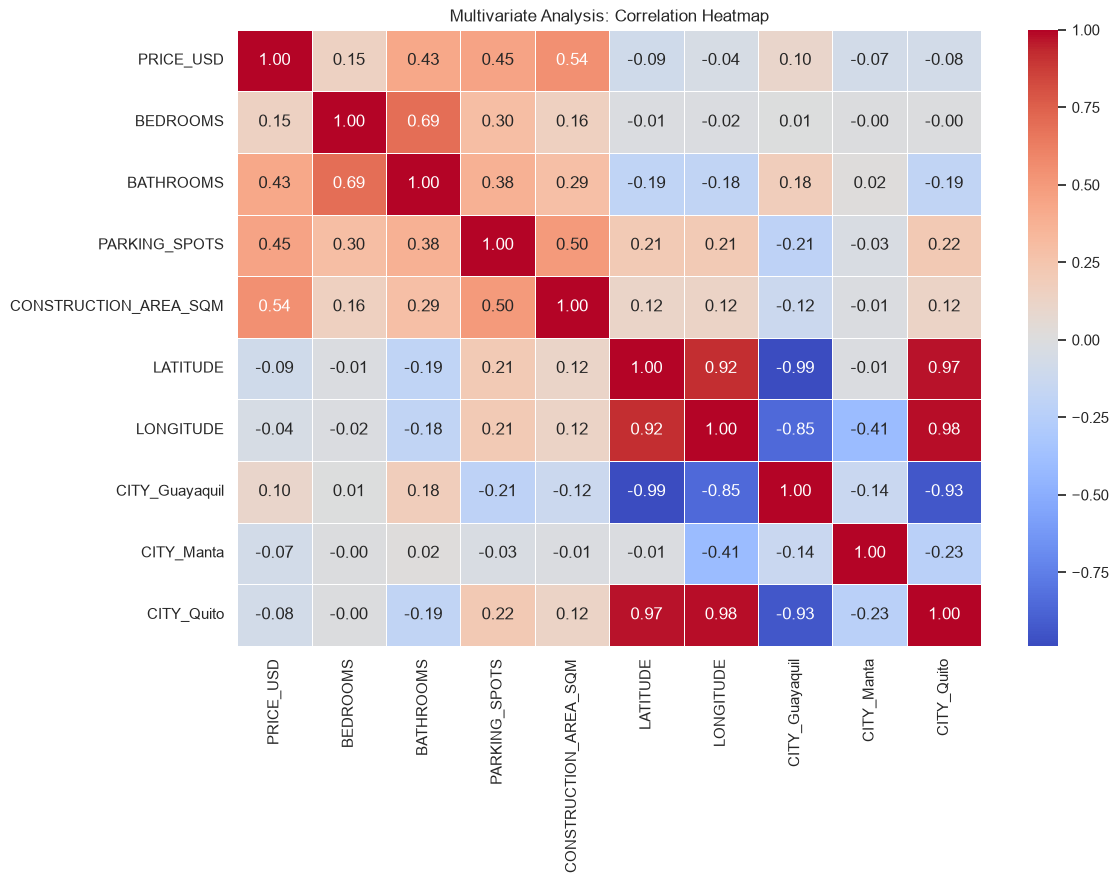

In [15]:
# 3. Multivariate Analysis: Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df_processed.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Multivariate Analysis: Correlation Heatmap')
plt.show()

Conclusiones del Análisis Exploratorio de Datos (EDA)
Tras realizar el análisis visual y estadístico del dataset df_processed, se pueden extraer las siguientes conclusiones clave para el modelado:

Distribución de Precios (Univariado):

La mayoría de las propiedades se encuentran en el rango de 100,000 a 400,000 USD.
Existe un sesgo a la derecha, indicando que las propiedades de lujo o muy costosas son menos frecuentes, incluso después de haber limitado los valores al percentil 99.
Relación Precio-Tamaño (Bivariado):

Se observa una correlación positiva clara entre CONSTRUCTION_AREA_SQM y PRICE_USD. A mayor metraje, el precio tiende a subir de forma lineal, aunque existe una dispersión considerable que sugiere que otros factores (como la ubicación o el número de baños) también influyen fuertemente.
El 'capping' en 5,000 m² es visible en el gráfico, evitando que valores extremos distorsionen la tendencia general.
Correlaciones y Multicolinealidad (Multivariado):

Factores Clave: El precio tiene las correlaciones más altas con el Área de Construcción (0.54), los Espacios de Estacionamiento (0.45) y el Número de Baños (0.43).
Multicolinealidad: Existe una correlación muy alta (0.69) entre BEDROOMS y BATHROOMS, lo cual es lógico (más habitaciones suelen implicar más baños). Esto es importante tenerlo en cuenta para modelos que no manejan bien la redundancia.
Ubicación: Las variables de latitud y longitud muestran una correlación casi perfecta con las columnas de las ciudades (CITY_Quito, CITY_Guayaquil), lo que confirma que estas coordenadas delimitan geográficamente las zonas analizadas de manera precisa.
Estado del Dataset:

El dataset está limpio y balanceado en términos de tipos de datos.
La aplicación de One-Hot Encoding permite que el modelo interprete la ciudad como un factor determinante sin imponer un orden arbitrario.

In [16]:
from pathlib import Path

# Crear carpeta si no existe
Path("../data/processed").mkdir(parents=True, exist_ok=True)

# Guardar CSV
df_processed.to_csv(
    "../data/processed/plusvalia_procesado.csv",
    index=False,
    encoding="utf-8-sig"
)

print("El archivo 'plusvalia_procesado.csv' se ha generado y la descarga ha comenzado.")

El archivo 'plusvalia_procesado.csv' se ha generado y la descarga ha comenzado.


Entrenamiento de Modelo

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [18]:
#Cargar el archivprocesado
df_processed = pd.read_csv('../data/processed/plusvalia_procesado.csv')

In [19]:
# 1. Definir variables predictoras (X) y variable objetivo (y)
X = df_processed.drop(columns=['PRICE_USD'])
y = df_processed['PRICE_USD']

In [20]:
# 2. Dividir el dataset en entrenamiento y prueba (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
print("Valores nulos en X_train:")
print(X_train.isna().sum())

print("\nValores nulos en y_train:")
print(y_train.isna().sum())

print("\nTipos de datos:")
print(X_train.dtypes)


Valores nulos en X_train:
BEDROOMS                 0
BATHROOMS                0
PARKING_SPOTS            0
CONSTRUCTION_AREA_SQM    0
LATITUDE                 0
LONGITUDE                0
CITY_Guayaquil           0
CITY_Manta               0
CITY_Quito               0
dtype: int64

Valores nulos en y_train:
0

Tipos de datos:
BEDROOMS                   int64
BATHROOMS                  int64
PARKING_SPOTS              int64
CONSTRUCTION_AREA_SQM    float64
LATITUDE                 float64
LONGITUDE                float64
CITY_Guayaquil           float64
CITY_Manta               float64
CITY_Quito               float64
dtype: object


In [22]:
import numpy as np
import pandas as pd

feature_columns = [
    "BEDROOMS",
    "BATHROOMS",
    "PARKING_SPOTS",
    "CONSTRUCTION_AREA_SQM",
    "LATITUDE",
    "LONGITUDE",
    "CITY_Guayaquil",
    "CITY_Manta",
    "CITY_Quito",
]

target_column = "PRICE_USD"

# Seleccionar únicamente las columnas del modelo
df_model = df_processed[
    feature_columns + [target_column]
].copy()

# Convertir todo a valores numéricos
for column in feature_columns + [target_column]:
    df_model[column] = pd.to_numeric(
        df_model[column],
        errors="coerce",
    )

# Reemplazar infinitos por NaN
df_model = df_model.replace(
    [np.inf, -np.inf],
    np.nan,
)

print(df_model.isna().sum())

BEDROOMS                 0
BATHROOMS                0
PARKING_SPOTS            0
CONSTRUCTION_AREA_SQM    0
LATITUDE                 0
LONGITUDE                0
CITY_Guayaquil           0
CITY_Manta               0
CITY_Quito               0
PRICE_USD                0
dtype: int64


In [23]:
numeric_columns = [
    "BEDROOMS",
    "BATHROOMS",
    "PARKING_SPOTS",
    "CONSTRUCTION_AREA_SQM",
    "LATITUDE",
    "LONGITUDE",
]

for column in numeric_columns:
    df_model[column] = df_model[column].fillna(
        df_model[column].median()
    )

In [24]:
city_columns = [
    "CITY_Guayaquil",
    "CITY_Manta",
    "CITY_Quito",
]

for column in city_columns:
    df_model[column] = df_model[column].fillna(0)

In [25]:
df_model = df_model.dropna(
    subset=[target_column]
)

In [27]:
X = df_model[feature_columns]
y = df_model[target_column]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

print("\nNulos en X:")
print(X.isna().sum())

print("\nNulos en y:")
print(y.isna().sum())

Dimensiones de X: (7459, 9)
Dimensiones de y: (7459,)

Nulos en X:
BEDROOMS                 0
BATHROOMS                0
PARKING_SPOTS            0
CONSTRUCTION_AREA_SQM    0
LATITUDE                 0
LONGITUDE                0
CITY_Guayaquil           0
CITY_Manta               0
CITY_Quito               0
dtype: int64

Nulos en y:
0


In [28]:
# 3. Inicializar y entrenar el modelo de Regresión Lineal
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

model = LinearRegression()

model.fit(
    X_train,
    y_train,
)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


In [29]:
# 4. Realizar predicciones sobre el conjunto de prueba
y_pred = model.predict(X_test)

In [31]:
# 5. Evaluación del modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Resultados del Modelo:")
print(f"- Error Cuadrático Medio (MSE): {mse:,.2f}")
print(f"- Coeficiente de determinación (R^2): {r2:.4f}")
print(f"- Raíz Cuadrada del Error Cuadrático Medio (RMSE): {rmse:,.2f}")

Resultados del Modelo:
- Error Cuadrático Medio (MSE): 48,454,685,630.38
- Coeficiente de determinación (R^2): 0.4940
- Raíz Cuadrada del Error Cuadrático Medio (RMSE): 220,124.25


In [32]:
# Mostrar coeficientes de las variables ordenados por impacto
coefficients = pd.DataFrame({'Variable': X.columns, 'Coeficiente': model.coef_.round(2)})

print("\nImpacto de cada variable en el precio (Ordenado de mayor a menor):")
display(coefficients.sort_values(by='Coeficiente', ascending=False))

print("\nIntercepto del modelo:", round(model.intercept_, 2))


Impacto de cada variable en el precio (Ordenado de mayor a menor):


,Variable,Coeficiente
5,LONGITUDE,1117606.45
7,CITY_Manta,1068259.19
6,CITY_Guayaquil,317561.64
1,BATHROOMS,70031.18
2,PARKING_SPOTS,34405.50
4,LATITUDE,600.78
3,CONSTRUCTION_AREA_SQM,160.19
0,BEDROOMS,-32948.43
8,CITY_Quito,-1385820.83



Intercepto del modelo: 89087194.62


Puntos Clave del Modelo de Regresión Lineal
Tras entrenar y evaluar el modelo para predecir PRICE_USD, se destacan los siguientes hallazgos:

Precisión del Modelo (R²: 0.4940):

El modelo logra explicar aproximadamente el 49.4% de la variación en los precios de las propiedades. Aunque es un buen punto de partida para una regresión lineal simple, sugiere que existen otros factores (o relaciones no lineales) que influyen en el precio final.
Error de Predicción (RMSE: 220,124.25 USD):

La Raíz del Error Cuadrático Medio indica que, en promedio, las predicciones del modelo se desvían unos $220,124 USD del precio real. Este margen de error debe considerarse al valorar propiedades de alto costo.
Factores con Mayor Impacto Positivo:

Ubicación (Manta y Guayaquil): Pertenecer a estas ciudades incrementa significativamente el valor base en comparación con la categoría de referencia.

Baños y Estacionamientos: Cada baño adicional suma aproximadamente 70,031 USD al valor, mientras que cada parqueadero incrementa unos $34,405 USD.

Área de Construcción: Cada metro cuadrado adicional incrementa el precio en $160 USD.

Hallazgo Inusual en Habitaciones:

El coeficiente negativo en BEDROOMS sugiere que, para una misma área de construcción, un mayor número de habitaciones (posiblemente más pequeñas) no necesariamente incrementa el precio, o que esta variable está capturada de forma más eficiente por el número de baños.
Conclusión Técnica:

El intercepto de la ecuación es considerablemente alto, actuando como el precio base ajustado por las coordenadas geográficas (Latitud/Longitud). Para mejorar estos resultados, se recomienda probar modelos de ensamble como Random Forest o XGBoost.

Random Forest

In [33]:
from sklearn.ensemble import RandomForestRegressor

In [34]:
# 1. Inicializar el modelo de Random Forest
# Usamos random_state para reproducibilidad y n_estimators=100 por defecto
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [35]:
#2. Dividir el dataset en entrenamiento y prueba (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
# 3. Entrenar el modelo
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [37]:
# 4. Realizar predicciones
y_pred_rf = rf_model.predict(X_test)

In [38]:
# 5. Evaluación del modelo
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print(f"Resultados del Modelo Random Forest:")
print(f"- Coeficiente de determinación (R^2): {r2_rf:.4f}")
print(f"- Raíz del Error Cuadrático Medio (RMSE): {rmse_rf:,.2f} USD")

Resultados del Modelo Random Forest:
- Coeficiente de determinación (R^2): 0.7961
- Raíz del Error Cuadrático Medio (RMSE): 139,736.24 USD


In [39]:
import pandas as pd

# Crear un DataFrame con las métricas de ambos modelos
comparacion_metricas = pd.DataFrame({
    'Métrica': ['R² (Precisión)', 'RMSE (Error promedio)'],
    'Regresión Lineal': [f"{r2:.4f}", f"${rmse:,.2f}"],
    'Random Forest': [f"{r2_rf:.4f}", f"${rmse_rf:,.2f}"]
})

print("Comparativa de Métricas: Regresión Lineal vs. Random Forest")
display(comparacion_metricas)

Comparativa de Métricas: Regresión Lineal vs. Random Forest


,Métrica,Regresión Lineal,Random Forest
0,R² (Precisión),0.4940,0.7961
1,RMSE (Error promedio),"$220,124.25","$139,736.24"


Análisis de la Comparativa
R² (Coeficiente de Determinación): Mientras que la Regresión Lineal solo explicaba el 49.4% de la variabilidad de los precios, el Random Forest logra explicar el 79.6%. Esto indica que el Random Forest es mucho mejor para capturar patrones complejos en los datos inmobiliarios.
RMSE (Error Cuadrático Medio): El error promedio de las predicciones bajó de 220,124 a 139,736. Esta reducción de error hace que el modelo sea mucho más confiable para estimar el valor real de una propiedad.

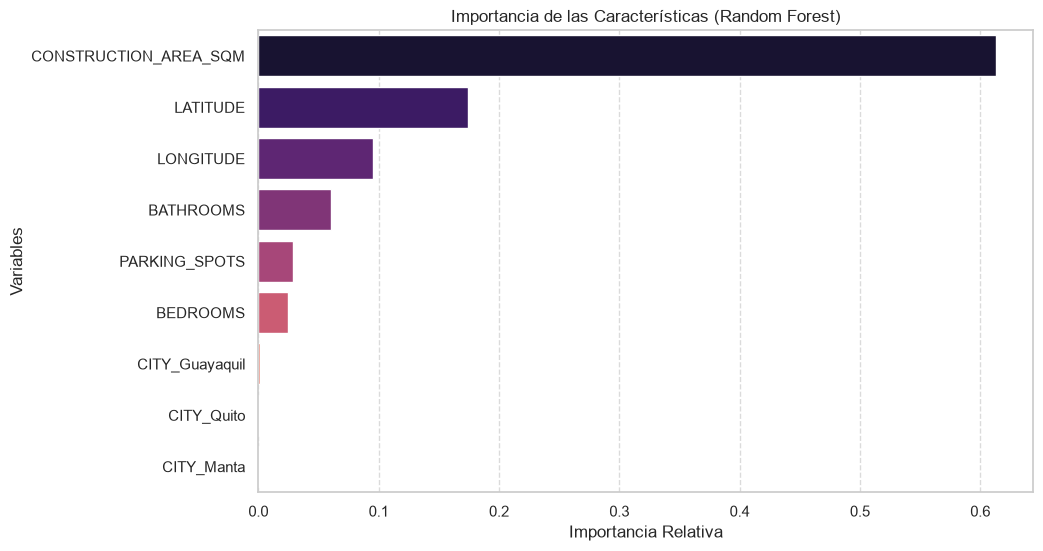

,Feature,Importance
3,CONSTRUCTION_AREA_SQM,0.613482
4,LATITUDE,0.174623
5,LONGITUDE,0.095655
1,BATHROOMS,0.060655
2,PARKING_SPOTS,0.029038
0,BEDROOMS,0.024612
6,CITY_Guayaquil,0.001580
8,CITY_Quito,0.000214
7,CITY_Manta,0.000141


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Obtener la importancia de las características del modelo
importances = rf_model.feature_importances_
feature_names = X.columns

# 2. Crear un DataFrame para la visualización
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Graficar las importancias (Corregido para eliminar el FutureWarning)
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    palette='magma',
    hue='Feature',
    legend=False
)
plt.title('Importancia de las Características (Random Forest)')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variables')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Mostrar tabla de valores
display(feature_importance_df)

Conclusiones: Importancia de las Características
El análisis de importancia del modelo Random Forest nos permite entender qué factores determinan realmente el precio de los inmuebles:

Dominio del Área de Construcción (~61.3%): Es el predictor más crítico. El tamaño físico de la propiedad es el factor que más influye en el precio final, confirmando la relación lineal observada en el EDA.
Impacto de la Ubicación Precisa (Latitud y Longitud): Sumadas, las coordenadas geográficas representan más del 27% de la importancia. Esto indica que el modelo otorga mucho más valor a la ubicación específica (microzonas o barrios) que a la ciudad en general (CITY_*), las cuales tienen una importancia mínima.
Configuración del Inmueble:
El número de baños (~6.0%) es más relevante que el número de habitaciones o estacionamientos.
Esto sugiere que la funcionalidad y el nivel de equipamiento del hogar tienen un peso significativo en la valoración.
Eficiencia del Modelo: Gracias a esta jerarquía de variables, el modelo Random Forest logra una precisión superior (R²: 0.79) al capturar cómo interactúan el tamaño y la ubicación exacta de manera no lineal.

Entrenamiento Final y Exportación del Modelo
En esta etapa final, entrenamos el modelo con el 100% de los datos procesados para asegurar que capture todos los patrones disponibles antes de ser guardado para su uso posterior.

In [41]:
import joblib
from sklearn.ensemble import RandomForestRegressor

# 1. Inicializar el modelo con los parámetros óptimos identificados
rf_final = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Entrenar con el dataset completo (X e y contienen todos los registros)
rf_final.fit(X, y)

# 3. Guardar el modelo en formato .pkl
model_filename = '../models/modelo_inmobiliario.pkl'
joblib.dump(rf_final, model_filename)

print(f"Modelo entrenado con {len(X)} registros.")
print(f"Archivo '{model_filename}' generado con éxito.")

Modelo entrenado con 7459 registros.
Archivo '../models/modelo_inmobiliario.pkl' generado con éxito.


In [42]:
from pathlib import Path
archivo = Path("../models/modelo_inmobiliario.pkl")

print(archivo.exists())
print(archivo.resolve())

True
D:\Proyectos Python\proyecto-prediccion-casas\models\modelo_inmobiliario.pkl


Prueba de Predicción Individual
Vamos a simular la entrada de datos para una propiedad hipotética y observar qué precio estima nuestro modelo final entrenado.

In [43]:
import numpy as np

# 1. Definir los datos de una propiedad de ejemplo
# Estructura: [BEDROOMS, BATHROOMS, PARKING_SPOTS, CONSTRUCTION_AREA_SQM, LATITUDE, LONGITUDE, CITY_Guayaquil, CITY_Manta, CITY_Quito]

# Ejemplo: Propiedad en Quito, 200 m2, 3 hab, 2 baños, 2 parking
ejemplo_propiedad = pd.DataFrame({
    'BEDROOMS': [3],
    'BATHROOMS': [2],
    'PARKING_SPOTS': [2],
    'CONSTRUCTION_AREA_SQM': [200.0],
    'LATITUDE': [-0.18],
    'LONGITUDE': [-78.48],
    'CITY_Guayaquil': [0.0],
    'CITY_Manta': [0.0],
    'CITY_Quito': [1.0]
})

# 2. Realizar la predicción
precio_estimado = rf_final.predict(ejemplo_propiedad)[0]

print(f"--- Datos de la Propiedad ---")
print(f"Área: {ejemplo_propiedad['CONSTRUCTION_AREA_SQM'][0]} m²")
print(f"Ubicación: Quito (Lat: -0.18, Long: -78.48)")
print(f"Habitaciones/Baños: {ejemplo_propiedad['BEDROOMS'][0]} / {ejemplo_propiedad['BATHROOMS'][0]}")
print(f"\n>>> PRECIO ESTIMADO POR EL MODELO: ${precio_estimado:,.2f} USD")

--- Datos de la Propiedad ---
Área: 200.0 m²
Ubicación: Quito (Lat: -0.18, Long: -78.48)
Habitaciones/Baños: 3 / 2

>>> PRECIO ESTIMADO POR EL MODELO: $193,165.03 USD


Nota sobre la Ubicación del Ejemplo
Las coordenadas geográficas utilizadas en la celda anterior (Latitud: -0.18, Longitud: -78.48) corresponden a un sector céntrico en Quito, Ecuador. El modelo utiliza esta precisión geográfica junto con el área y las comodidades para calcular el valor estimado de mercado.